<a href="https://colab.research.google.com/github/Greeshma-babu/AI_Projects/blob/main/ImageClassificationResNet_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms,models
import os

In [2]:
from google.colab import files
uploaded = files.upload()

Saving datasets.zip to datasets.zip


In [4]:
import zipfile

with zipfile.ZipFile("datasets.zip", "r") as zip_ref:
    zip_ref.extractall()

In [5]:
import os
print(os.listdir())

['.config', 'datasets', 'datasets.zip', 'sample_data']


In [6]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root, "->", dirs, files[:3])

In [52]:
import os

print("datasets:")
print(os.listdir("datasets"))

print("\ntrain:")
print(os.listdir("datasets/train"))

print("\nval:")
print(os.listdir("datasets/val"))

datasets:
['train', 'val']

train:
['Dog', 'Cat']

val:
['Dog', 'Cat']


In [7]:
# Define data transformations for data Augumentation and Normalization
# transforms.ToTensor() is used to convert an image into a PyTorch tensor,
# because NN in PyTorch cannot process images in their original format (such as PIL images or NumPy arrays).
# Converts the image to a PyTorch Tensor PIL Image → torch.Tensor, Scales pixel values from [0, 255] to [0.0, 1.0]
# Normalize() expects a tensor, not a PIL image.
# This normalization makes the input distribution similar to what many pretrained models (such as ResNet and VGG) expect.

data_transforms ={
    'train' : transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
  'val': transforms.Compose([
      transforms.Resize(256),
      transforms.CenterCrop(224),
      transforms.ToTensor(),
      transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
  ])
}

In [9]:
# Create the data loader
data_dir = 'datasets' # Define the data directory
# ImageFolder() expects two arguments: folder path, transform
Image_dataset = {
    x : datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x])
    for x in ['train', 'val']
}

In [10]:
dataloader = {
    x: torch.utils.data.DataLoader(
        Image_dataset[x],
        batch_size=4,
        shuffle=True,
        num_workers=4)
    for x in ['train', 'val']
}
datasets_sizes = {
    x: len(Image_dataset[x])
    for x in ['train', 'val']
}
print("datasets_sizes=", datasets_sizes)
class_names = Image_dataset['train'].classes
print("Output_Labels= ",  class_names)

datasets_sizes= {'train': 10, 'val': 2}
Output_Labels=  ['Cat', 'Dog']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


**Load Pretrained Model**

In [12]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


**Freeze all layers Except Final layer**

In [13]:
for name, param in model.named_parameters():
  if 'fc' in name: # fc means the fully connected layer - final classification layer
    param.requires_grad=True # Update the weight during training
  else:
    param.requires_grad=False # Freeze the weight
# Freeze will prevent training the pretrained knowledge
# Forozen layer acts as a feature extractor
# Final layer learns your dataset


**Define Loss Function**

In [14]:
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss - used for multi class classification problems
# It give the output value and label
# Softmax is an activation function that converts the model's output (called logits)
# into probabilities. between 0 and 1 and sum is 1.
# Example: The model's raw outputs (logits) are [2.5, 1.2, 0.3] -> softmax activation converts [2.5, 1.2, 0.3]

**Define Optimizer**

In [15]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# The optimizer uses the gradients to change the model's weights.
# old weight -> Gradient calculate -> Optimizer -> New weight
# SGD - Stochastic Gradient descent - updates the weights during training
# lr = Learning Rate → How much the model's weights change after each update.
# momentum = Memory of previous steps → Which direction the optimizer keeps moving.

**Move Model to Device (GPU/CPU)**

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Check if GPU is available True -NVIDIA GPU is available

**Steps:**


1. Loop over Epochs
2. Training & Validation phases
3. Set model mode
4. Initialize Metrics
5. Loop Over Data
6. Move data to device
7. Reset Gradient
8. Forward Pass + Loss Computation
9. Backprogation (Training Only)
10. Compute Epoch Metrics




In [26]:
num_epochs = 10
for epoch in range(num_epochs):
  for phase in ['train', 'val']:
    if phase == 'train':
      model.train()
    else :
      model.eval()
    running_loss = 0.0 # Tracks total loss across all batch
    running_correct = 0 # Counts corectly predicted samples

    for input, label in dataloader[phase]:
      inputs = input.to(device) # Move data to device. Already moved model to device.
      labels = label.to(device) # Move label to device
      optimizer.zero_grad() # Reset the gradients to zero
      with torch.set_grad_enabled(phase == 'train'):
        outputs = model(inputs) #
        _,preds = torch.max(outputs,1)
        loss = criterion(outputs, labels)
        torch.set_grad_enabled(mode=True)
        if phase == 'train':
          loss.backward() # Compute gradient
          optimizer.step() #Update the model weights
        running_loss += loss.item() * input.size(0) # Converts tensor to scalar value , Batch Size
        running_correct +=torch.sum(preds == labels.data) # Count the correct predictions
        epoch_loss = running_loss / datasets_sizes[phase] # Accuray loss
        epoch_acc = running_correct.double()/datasets_sizes[phase] # Accuary over entire datasets
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
print("### TRAINING COMPLETED !!!")





train Loss: 0.0341 Acc: 0.4000
train Loss: 0.0441 Acc: 0.8000
train Loss: 0.3127 Acc: 0.9000
val Loss: 0.0136 Acc: 1.0000
train Loss: 0.0036 Acc: 0.4000
train Loss: 0.0084 Acc: 0.8000
train Loss: 0.0354 Acc: 1.0000
val Loss: 0.0152 Acc: 1.0000
train Loss: 0.0010 Acc: 0.4000
train Loss: 0.0019 Acc: 0.8000
train Loss: 0.0054 Acc: 1.0000
val Loss: 0.0194 Acc: 1.0000
train Loss: 0.1809 Acc: 0.3000
train Loss: 0.3804 Acc: 0.6000
train Loss: 0.3812 Acc: 0.8000
val Loss: 0.0187 Acc: 1.0000
train Loss: 0.0466 Acc: 0.4000
train Loss: 0.0639 Acc: 0.8000
train Loss: 0.3720 Acc: 0.9000
val Loss: 0.0174 Acc: 1.0000
train Loss: 0.0025 Acc: 0.4000
train Loss: 0.0298 Acc: 0.8000
train Loss: 0.1795 Acc: 0.8000
val Loss: 0.0108 Acc: 1.0000
train Loss: 0.0157 Acc: 0.4000
train Loss: 0.1259 Acc: 0.7000
train Loss: 0.1302 Acc: 0.9000
val Loss: 0.0128 Acc: 1.0000
train Loss: 0.0018 Acc: 0.4000
train Loss: 0.0062 Acc: 0.8000
train Loss: 0.0063 Acc: 1.0000
val Loss: 0.0104 Acc: 1.0000
train Loss: 0.0021 Acc: 

In [34]:
torch.save(model.state_dict(), "Dog_classification_model.pth")
# Save the model

**Classification on Unseen Image**

In [29]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
# transforms for preprocess the image
# torch.nn-> Used for neural network layer
# PIL -> Used to load and handle image files

**Load Model Architecture**

In [31]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Model Final Layer**

In [32]:
model.fc = nn.Linear(model.fc.in_features,2)
# 2 -> Binary Classification


**Load Trained Weights**

In [37]:
model.load_state_dict(torch.load("Dog_classification_model.pth"))
#torch.load(path, map_location=device)

<All keys matched successfully>

**Set model too Evaluation Mode**

In [38]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Image Preprocessing**

In [42]:
from google.colab import files
uploaded = files.upload()
image_name = list(uploaded.keys())[0]   # Get the uploaded filename
image = Image.open(image_name).convert("RGB")

Saving Test_Dog_Image.jpg to Test_Dog_Image (1).jpg


In [43]:
preprocess = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]
)
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0) # Add a batch dimensions
# Even for a single image, we need to pass a batch

**Disable Gradient Computation & Predict the class index**

In [46]:
with torch.no_grad(): # Turned off the gradient
  output = model(input_batch) # logits from the model
  _,predicted_class = output.max(1)
  print(predicted_class)

tensor([0])


**Map index to class name from class index**

In [48]:
class_names = ['Dog','Cat']
print(f'The predicted class is {predicted_class}')

predicted_label = class_names[predicted_class.item()]
print(f"Predicted class: {predicted_label}")

The predicted class is tensor([0])
Predicted class: Dog


**Find probabilties**

In [50]:
probs = torch.softmax(output, dim=1)
print("Probabilties=", probs)

Probabilties= tensor([[0.5735, 0.4265]])


**Predicted Image**

Text(0, 0, 'Predicted: Dog')

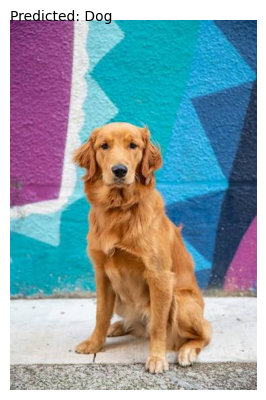

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(0,0,f'Predicted: {predicted_label}')